In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from wordcloud import WordCloud

In [2]:
df = pd.read_csv("/kaggle/input/datasets/thnhtrungnguynmif/vietnamhistory-nli/data_tk1_NLI_VietnamHistory.csv")

print("Số dòng dataset:", len(df))


Số dòng dataset: 2239


In [3]:
df

,premise,contradiction,entailment,neutral
0,"Ngày 22 tháng 12 năm 1944, Võ Nguyên Giáp thàn...",Việt Nam Tuyên truyền Giải phóng quân được thà...,Việt Nam Tuyên truyền Giải phóng quân được thà...,"Cuối năm 1944, phong trào vũ trang cách mạng ở..."
1,Việt Nam Tuyên truyền Giải phóng quân là một t...,Việt Nam Tuyên truyền Giải phóng quân không có...,Việt Nam Tuyên truyền Giải phóng quân là lực l...,Quân đội Nhân dân Việt Nam được phát triển từ ...
2,"ngày 12 tháng 3 năm 1945, Ban Thường vụ Trung ...",Chỉ thị được ban hành để kêu gọi hợp tác với q...,"Tháng 3 năm 1945, Đảng Cộng sản Việt Nam đã kê...","Trong năm 1945, Đảng Cộng sản Đông Dương phải ..."
3,"Dưới sự cai trị của Nhật, từ tháng 10 năm 1944...",Nạn đói năm 1945 không gây thiệt hại lớn về nh...,"Trong thời gian Nhật chiếm đóng, Việt Nam xảy ...",Chiến tranh thế giới thứ hai gây hậu quả nặng ...
4,"Cách mạng Tháng Tám, còn gọi là Tổng khởi nghĩ...",Cách mạng Tháng Tám diễn ra hòa bình và không ...,Cách mạng Tháng Tám năm 1945 đã lật đổ chính q...,Nhiều cuộc nổi dậy diễn ra ở Việt Nam trong gi...
...,...,...,...,...
2234,Miền Bắc đã thu hồi 810.000 ha ruộng đất từ đị...,Miền Bắc không thu hồi ruộng đất từ địa chủ để...,Miền Bắc thu hồi 810.000 ha ruộng đất của địa ...,Việc chia lại ruộng đất cho nông dân nghèo làm...
2235,Có 23 đảng phái phản động hoạt động bí mật tại...,Không có đảng phái phản động nào hoạt động bí ...,Sau năm 1954 lực lượng an ninh triệt phá 23 đả...,Một số tổ chức chính trị phản động bị triệt ph...
2236,Mỹ dùng 41 tàu thủy hỗ trợ kế hoạch di cư giáo...,Mỹ không sử dụng tàu thủy nào hỗ trợ kế hoạch ...,Năm 1954 Mỹ sử dụng 41 tàu thủy hỗ trợ kế hoạc...,Các tàu thủy được sử dụng trong kế hoạch di cư...
2237,Tổng số báo miền Bắc ấn hành vào năm 1957 đạt ...,Tổng số báo miền Bắc ấn hành vào năm 1957 chỉ ...,Năm 1957 tổng số báo in tại miền Bắc đạt khoản...,Số lượng báo chí phát hành lớn phản ánh nhu cầ...


In [4]:
total_pairs = len(df) * 3

print("Số dòng:", len(df))
print("Số cặp NLI:", total_pairs)

Số dòng: 2239
Số cặp NLI: 6717


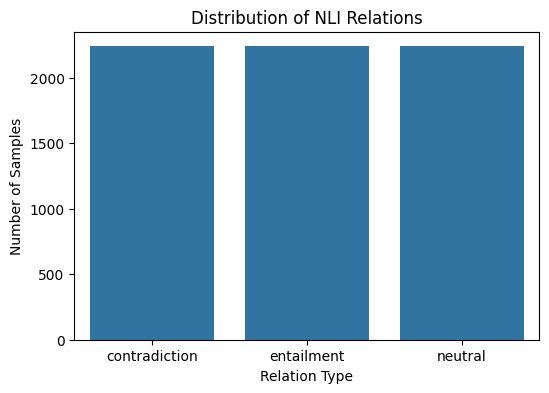

In [9]:
labels = ['contradiction', 'entailment', 'neutral']
counts = [len(df), len(df), len(df)]

plt.figure(figsize=(6,4))
sns.barplot(x=labels, y=counts)

plt.title("Distribution of NLI Relations")
plt.xlabel("Relation Type")
plt.ylabel("Number of Samples")

plt.show()

In [12]:
df.columns = df.columns.str.strip().str.lower()

print(df.columns)


Index(['premise', 'contradiction', 'entailment', 'neutral'], dtype='object')


In [13]:
df["premise_length"] = df["premise"].astype(str).apply(lambda x: len(x.split()))
df["entailment_length"] = df["entailment"].astype(str).apply(lambda x: len(x.split()))
df["contradiction_length"] = df["contradiction"].astype(str).apply(lambda x: len(x.split()))
df["neutral_length"] = df["neutral"].astype(str).apply(lambda x: len(x.split()))

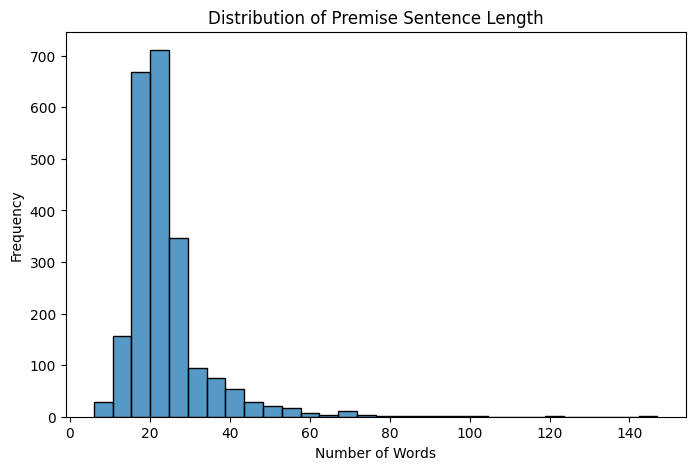

In [14]:
plt.figure(figsize=(8,5))

sns.histplot(df["premise_length"], bins=30)

plt.title("Distribution of Premise Sentence Length")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")

plt.show()

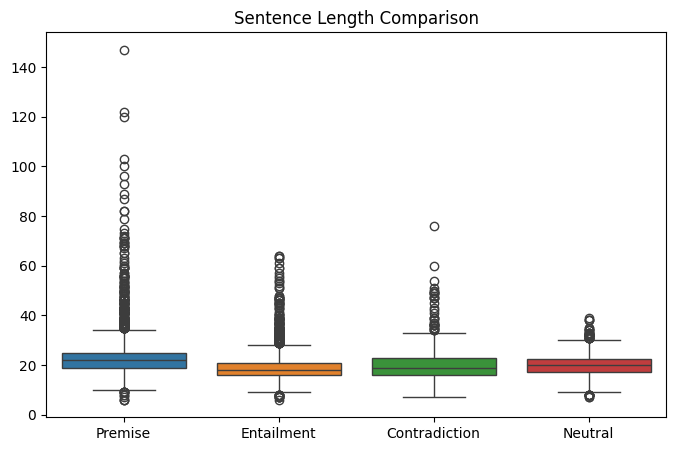

In [15]:
length_df = pd.DataFrame({
    "Premise": df["premise_length"],
    "Entailment": df["entailment_length"],
    "Contradiction": df["contradiction_length"],
    "Neutral": df["neutral_length"]
})

plt.figure(figsize=(8,5))

sns.boxplot(data=length_df)

plt.title("Sentence Length Comparison")

plt.show()

In [21]:
all_text = " ".join(df["premise"].astype(str))

words = all_text.lower().split()

word_freq = Counter(words)

top_words = word_freq.most_common(20)

words = [w[0] for w in top_words]
counts = [w[1] for w in top_words]

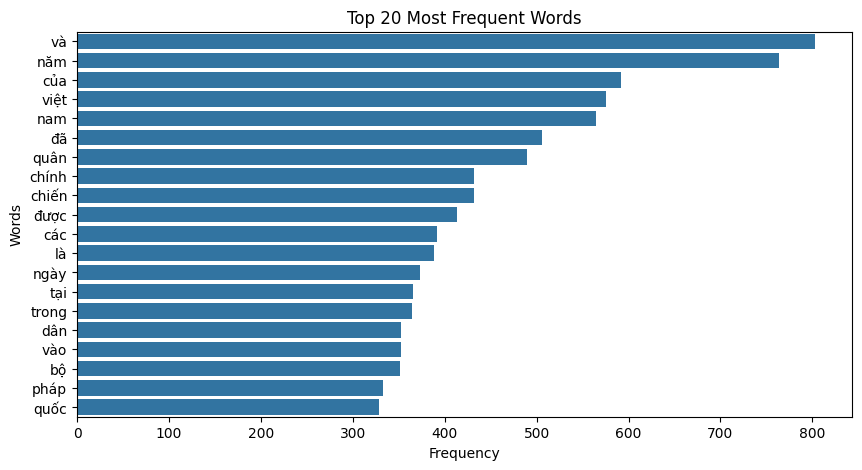

In [22]:
plt.figure(figsize=(10,5))

sns.barplot(x=counts, y=words)

plt.title("Top 20 Most Frequent Words")

plt.xlabel("Frequency")
plt.ylabel("Words")

plt.show()

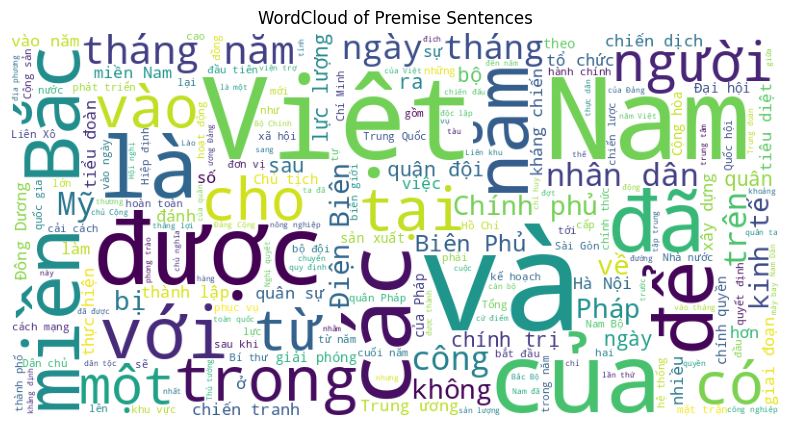

In [23]:
text = " ".join(df["premise"].astype(str))

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color='white'
).generate(text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud)
plt.axis("off")

plt.title("WordCloud of Premise Sentences")

plt.show()

In [24]:
print("Độ dài trung bình premise:", df["premise_length"].mean())
print("Premise dài nhất:", df["premise_length"].max())
print("Premise ngắn nhất:", df["premise_length"].min())

Độ dài trung bình premise: 24.088432335864226
Premise dài nhất: 147
Premise ngắn nhất: 6


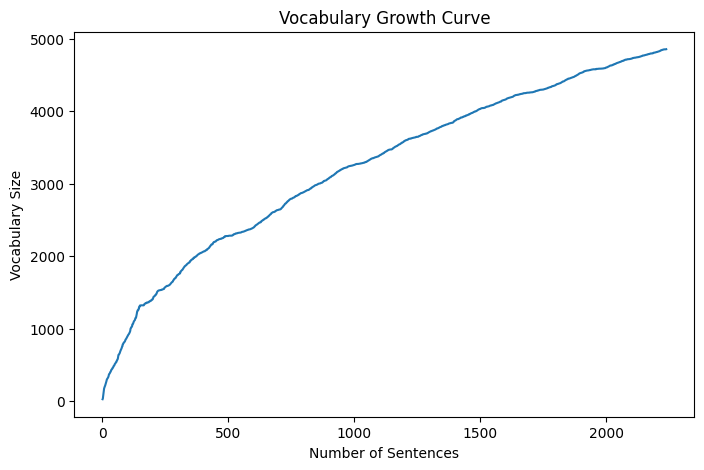

In [25]:
import matplotlib.pyplot as plt

texts = df["premise"].astype(str).tolist()

vocab_sizes = []
dataset_sizes = []

vocab = set()

for i, sentence in enumerate(texts):
    words = sentence.lower().split()
    vocab.update(words)

    vocab_sizes.append(len(vocab))
    dataset_sizes.append(i+1)

plt.figure(figsize=(8,5))

plt.plot(dataset_sizes, vocab_sizes)

plt.title("Vocabulary Growth Curve")
plt.xlabel("Number of Sentences")
plt.ylabel("Vocabulary Size")

plt.show()

In [26]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

model = SentenceTransformer("all-MiniLM-L6-v2")

premises = df["premise"].astype(str).tolist()
entailments = df["entailment"].astype(str).tolist()
contradictions = df["contradiction"].astype(str).tolist()
neutrals = df["neutral"].astype(str).tolist()

# encode
prem_emb = model.encode(premises)
ent_emb = model.encode(entailments)
con_emb = model.encode(contradictions)
neu_emb = model.encode(neutrals)

# similarity
sim_ent = cosine_similarity(prem_emb, ent_emb).diagonal()
sim_con = cosine_similarity(prem_emb, con_emb).diagonal()
sim_neu = cosine_similarity(prem_emb, neu_emb).diagonal()

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/350 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

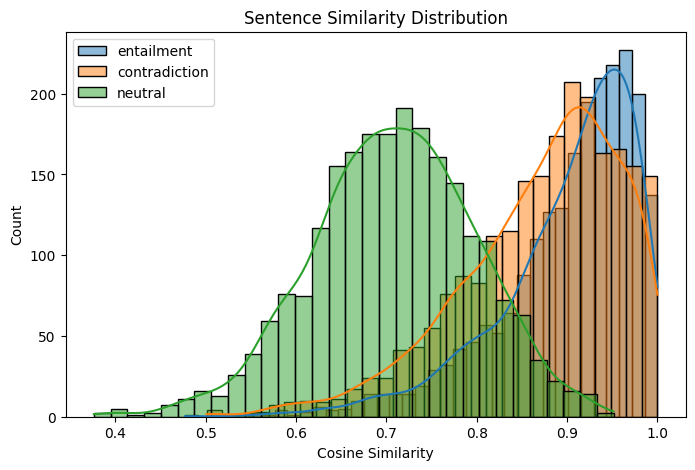

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

sns.histplot(sim_ent, label="entailment", kde=True)
sns.histplot(sim_con, label="contradiction", kde=True)
sns.histplot(sim_neu, label="neutral", kde=True)

plt.legend()

plt.title("Sentence Similarity Distribution")
plt.xlabel("Cosine Similarity")

plt.show()

In [28]:
from sklearn.manifold import TSNE
import numpy as np

embeddings = np.concatenate([prem_emb, ent_emb, con_emb, neu_emb])

labels = (
    ["premise"]*len(prem_emb) +
    ["entailment"]*len(ent_emb) +
    ["contradiction"]*len(con_emb) +
    ["neutral"]*len(neu_emb)
)

tsne = TSNE(n_components=2, random_state=42)

emb_2d = tsne.fit_transform(embeddings)

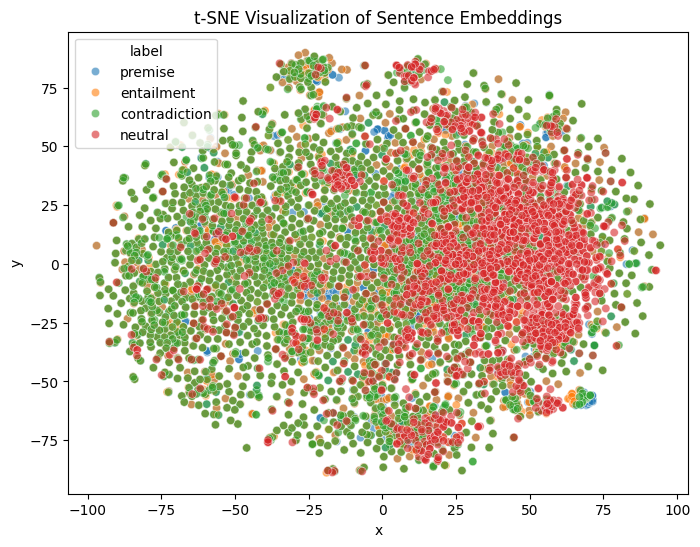

In [29]:
import pandas as pd

plot_df = pd.DataFrame({
    "x": emb_2d[:,0],
    "y": emb_2d[:,1],
    "label": labels
})

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=plot_df,
    x="x",
    y="y",
    hue="label",
    alpha=0.6
)

plt.title("t-SNE Visualization of Sentence Embeddings")

plt.show()